<a href="https://colab.research.google.com/github/Anna94652/10701-Secondary-Protein-Structure-Prediction/blob/main/701ProjectLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import re, os, random
import numpy as np
import pandas as pd
import math
from tqdm import tqdm
import string
import time
import pickle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
AA_VOCAB  = list('ACDEFGHIKLMNPQRSTVWXY')
SS8_VOCAB = ['C', 'B', 'E', 'G', 'I', 'H', 'S', 'T']
NUM_CLASSES = len(SS8_VOCAB)
MAX_LEN = 700

class ProteinDataset(Dataset):
    def __init__(self, df, max_len=MAX_LEN):
        self.df      = df.reset_index(drop=True)
        self.max_len = max_len
        self.aa_map  = {c: i for i, c in enumerate(AA_VOCAB)}
        self.ss_map  = {c: i for i, c in enumerate(SS8_VOCAB)}

    def __len__(self):
        return len(self.df)

    def encode(self, seq, vocab_map):
        arr = np.zeros(self.max_len, dtype=np.int64)
        for i, ch in enumerate(seq[:self.max_len]):
            if ch in vocab_map:
                arr[i] = vocab_map[ch]
        return arr

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        X      = self.encode(row['input'], self.aa_map)
        y      = self.encode(row['dssp8'], self.ss_map)
        length = min(len(row['input']), self.max_len)
        mask   = np.zeros(self.max_len, dtype=np.float32)
        mask[:length] = 1.0
        return (torch.tensor(X),
                torch.tensor(y),
                torch.tensor(mask))

In [4]:
full_train_df = pd.read_csv('/content/drive/MyDrive/10-701/701Project/train_data.csv')

train_df, val_df = train_test_split(full_train_df, test_size=0.2, random_state=42)

train_dataset = ProteinDataset(train_df)
val_dataset  = ProteinDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader  = DataLoader(val_dataset,  batch_size=32, shuffle=False)

In [27]:
lengths = full_train_df['input'].str.len()
print(lengths.describe())
print(f"Max:    {lengths.max()}")
print(f"Min:    {lengths.min()}")
print(f"Median: {lengths.median()}")
print(f"% over 700: {(lengths > 700).mean()*100:.1f}%")

count    10792.000000
mean       255.796238
std        161.926369
min         20.000000
25%        142.000000
50%        218.000000
75%        333.000000
max       1632.000000
Name: input, dtype: float64
Max:    1632
Min:    20
Median: 218.0
% over 700: 2.2%


In [5]:
for X, y, mask in tqdm(train_loader):
  print(X[1][:15])
  print(y[1][:15])
  print(mask[1][:15])
  break

  0%|          | 0/270 [00:00<?, ?it/s]

tensor([15, 11,  7, 11,  3, 14,  3,  8,  3, 14, 17,  0,  9, 11,  8])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


In [6]:
class ProteinModel(nn.Module):
  def __init__(self, AA_size, dim_embed, dim_model, dim_out, batch_size):
    super().__init__()
    self.AA_size = AA_size
    self.dim_embed = dim_embed
    self.dim_model = dim_model
    self.dim_out = dim_out
    self.batch_size = batch_size

    self.embed = torch.nn.Embedding(num_embeddings=AA_size, embedding_dim=dim_embed)
    self.LSTM = torch.nn.LSTM(input_size=dim_embed, hidden_size=dim_model, batch_first=True)
    self.lin = torch.nn.Linear(dim_model, dim_out)

  def forward(self, input):
    embeded = self.embed(input)
    x, _ = self.LSTM(embeded)
    x = self.lin(x)
    return x

  def init_hidden(self) -> torch.Tensor:
      # Initialize hidden state to zeros
      return torch.zeros((self.batch_size, self.hidden_size))

In [7]:
def train(data_loader, model, criterion, optimizer, device):
    train_avg_loss = 0
    num_correct = 0
    total_residues = 0

    model.train()  # Set model to training mode

    # Implement training loop
    for X, y, mask in tqdm(data_loader, leave=False):
        optimizer.zero_grad()
        X = X.to(device=device, dtype=torch.long)
        y = y.to(device=device, dtype=torch.long)
        mask = mask.to(device=device, dtype=torch.long)

        # Perform forward pass
        y_hat = model.forward(X)
        pred = y_hat.argmax(dim=-1).to(dtype=torch.long)

        # Calculate loss at every position and ignore padding
        loss = criterion(y_hat.reshape(-1, NUM_CLASSES), y.reshape(-1))
        loss = (loss * mask.reshape(-1)).sum() / mask.sum()

        # Calculate number of correct predictions (ignore masked values)
        corr = torch.sum((y == pred) * mask)
        total_residues += mask.sum().item()

        # Backward pass, update weights, and zero gradients
        loss.backward()
        optimizer.step()


        num_correct += corr.item()
        train_avg_loss += loss.item()


    # print the loss and accuracy at the end of each epoch
    final_loss = train_avg_loss/len(data_loader)
    final_acc = num_correct/total_residues
    print(f"Train loss: {final_loss} | Accuracy: {final_acc}")

    return final_loss, final_acc

In [8]:
def test(data_loader, model, criterion, device):
    test_avg_loss = 0
    num_correct = 0
    total_residues = 0

    model.eval() # Set model to eval mode

    # Implement testing loop
    with torch.no_grad():
      for X, y, mask in tqdm(data_loader, leave=False):
        X = X.to(device=device, dtype=torch.long)
        y = y.to(device=device, dtype=torch.long)
        mask = mask.to(device=device, dtype=torch.long)

        # Perform forward pass
        y_hat = model.forward(X)
        pred = y_hat.argmax(dim=-1).to(dtype=torch.long)

        # Calculate loss at every position and ignore padding
        loss = criterion(y_hat.reshape(-1, NUM_CLASSES), y.reshape(-1))
        loss = (loss * mask.reshape(-1)).sum() / mask.sum()

        # Calculate number of correct predictions (ignore masked values)
        corr = torch.sum((y == pred) * mask)
        total_residues += mask.sum().item()

        num_correct += corr.item()
        test_avg_loss += loss.item()

    # print the loss and accuracy at the end of each epoch
    final_loss = test_avg_loss/len(data_loader)
    final_acc = num_correct/total_residues
    print(f"Test loss: {final_loss} | Accuracy: {final_acc}")

    return final_loss, final_acc

In [9]:
def run(num_epochs, train_dataloader, test_dataloader, model, criterion, optimizer, device):
  train_losses, test_losses = [], []
  train_accs, test_accs = [], []
  for epoch in range(num_epochs):
    print(f"Epoch {epoch}")
    train_loss, train_acc = train(train_dataloader, model, criterion, optimizer, device)
    test_loss, test_acc = test(test_dataloader, model, criterion, device)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

  return train_losses, train_accs, test_losses, test_accs

In [15]:
# Count the frequency of each label in the training set
all_labels = ''.join(train_df['dssp8'].tolist())
counts = Counter(all_labels)
total  = sum(counts.values())

for cls, count in sorted(counts.items()):
    print(f"{cls}: {count:,} ({count/total*100:.1f}%)")

B: 21,289 (1.0%)
C: 545,789 (24.6%)
E: 445,572 (20.1%)
G: 80,081 (3.6%)
H: 716,962 (32.3%)
I: 11,524 (0.5%)
S: 168,480 (7.6%)
T: 227,027 (10.2%)


In [20]:
def main(
    # Hyperparameters
    AA_size = len(AA_VOCAB),
    batch_size = 32,
    dim_embed = 10,
    dim_model = 64,
    max_len = MAX_LEN,
    lr = 1e-4,
    num_epochs = 50,
    num_classes = NUM_CLASSES,
    weighted_loss = False
):
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    # Initialize model
    model = ProteinModel(AA_size=AA_size, dim_embed=dim_embed, dim_model=dim_model, dim_out=num_classes, batch_size=batch_size)
    model.to(device)

    # Initialize loss function and optimizer
    if weighted_loss:
      # Calculate inverse frequency weights
      freqs   = np.array([counts[c] for c in SS8_VOCAB], dtype=np.float32)
      weights = 1.0 / freqs
      weights = weights / weights.sum() * len(SS8_VOCAB)  # normalise

      criterion = nn.CrossEntropyLoss(
          weight=torch.tensor(weights).to(device),
          reduction='none'
      )
    else:
      criterion = torch.nn.CrossEntropyLoss(reduction='none').to(device=device)
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    # Run training and validation
    train_losses, train_accs, val_losses, val_accs = run(num_epochs=num_epochs, train_dataloader=train_loader,
                                                           test_dataloader=val_loader, model=model,
                                                            criterion=criterion, optimizer=optim, device=device)

    return train_losses, train_accs, val_losses, val_accs

In [21]:
train_losses, train_accs, val_losses, val_accs = main(weighted_loss=False)

Epoch 0


Train loss: 1.8813394692209031 | Accuracy: 0.26588529015955964


Test loss: 1.6631028389229494 | Accuracy: 0.33136497757604827
Epoch 1


Train loss: 1.6484806272718642 | Accuracy: 0.34341502061622714


Test loss: 1.6394266521229464 | Accuracy: 0.34504704084089355
Epoch 2


...

Test loss: 1.4413848624509924 | Accuracy: 0.45971247324149744
Epoch 48


Train loss: 1.4425107249507199 | Accuracy: 0.4613639004236687


Test loss: 1.441753154291826 | Accuracy: 0.45986924493898035
Epoch 49


Train loss: 1.4415999355139555 | Accuracy: 0.4621026447504325


Test loss: 1.4404509803828072 | Accuracy: 0.4603862182747275


In [22]:
def plot_losses(train_loss, val_loss, title):
  epochs = range(1, len(train_loss) + 1)
  plt.figure(figsize=(10, 6))

  plt.plot(epochs, train_loss, label='Train', color='blue')
  plt.plot(epochs, val_loss, label='Validation', color='red')

  plt.title(title)
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  plt.show()

In [23]:
def plot_accs(train_acc, val_acc, title):
  epochs = range(1, len(train_acc) + 1)
  plt.figure(figsize=(10, 6))

  plt.plot(epochs, train_acc, label='Train', color='blue')
  plt.plot(epochs, val_acc, label='Validation', color='red')

  plt.title(title)
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)

  plt.show()

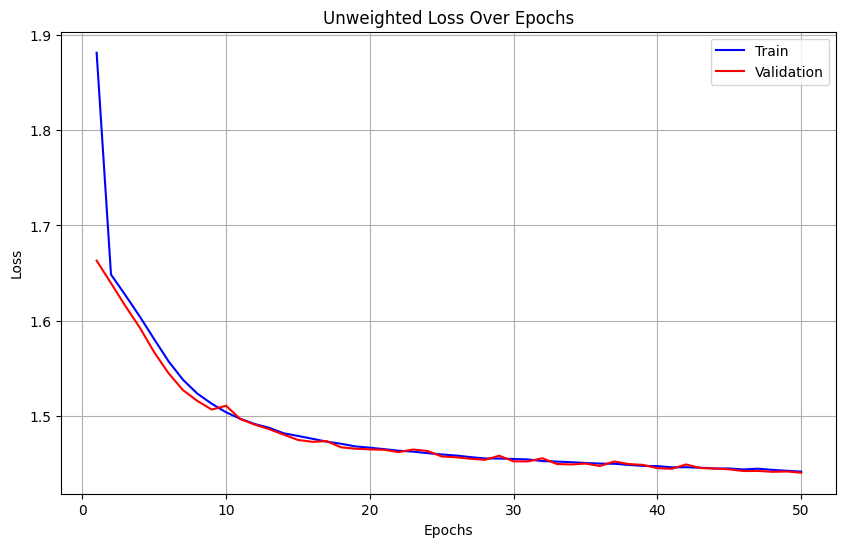

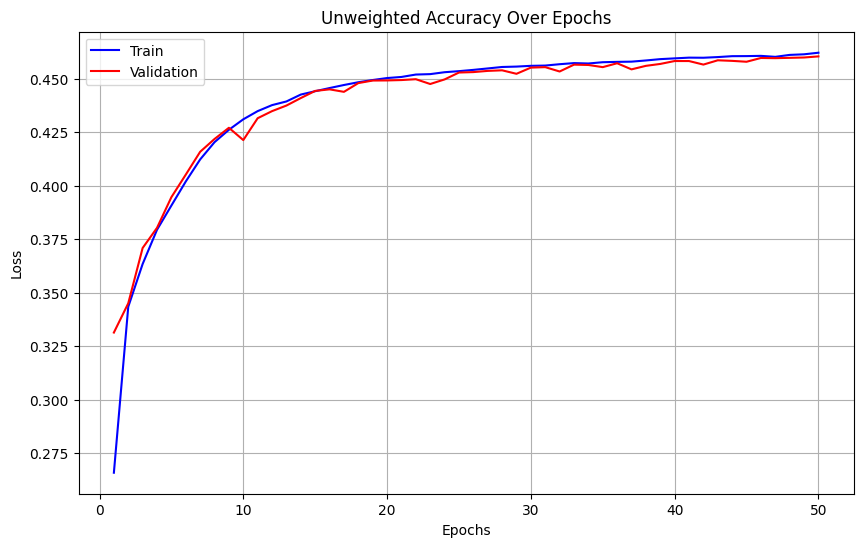

In [24]:
plot_losses(train_losses, val_losses, "Unweighted Loss Over Epochs")
plot_accs(train_accs, val_accs, "Unweighted Accuracy Over Epochs")

In [25]:
w_train_losses, w_train_accs, w_val_losses, w_val_accs = main(weighted_loss=True)

Epoch 0


Train loss: 0.36821826221766296 | Accuracy: 0.10595652066517179


Test loss: 0.3635447428506963 | Accuracy: 0.19485602199282956
Epoch 1


Train loss: 0.36340545184082457 | Accuracy: 0.2191257475497932


Test loss: 0.35626574781011133 | Accuracy: 0.23079033465158424
Epoch 2


...

Test loss: 0.3294290593441795 | Accuracy: 0.2872897346265754
Epoch 48


Train loss: 0.33073678579595356 | Accuracy: 0.29478505970792385


Test loss: 0.32891683280467987 | Accuracy: 0.295173111414286
Epoch 49


Train loss: 0.3304744831941746 | Accuracy: 0.29566194693665826


Test loss: 0.3288390303359312 | Accuracy: 0.29191636603205234


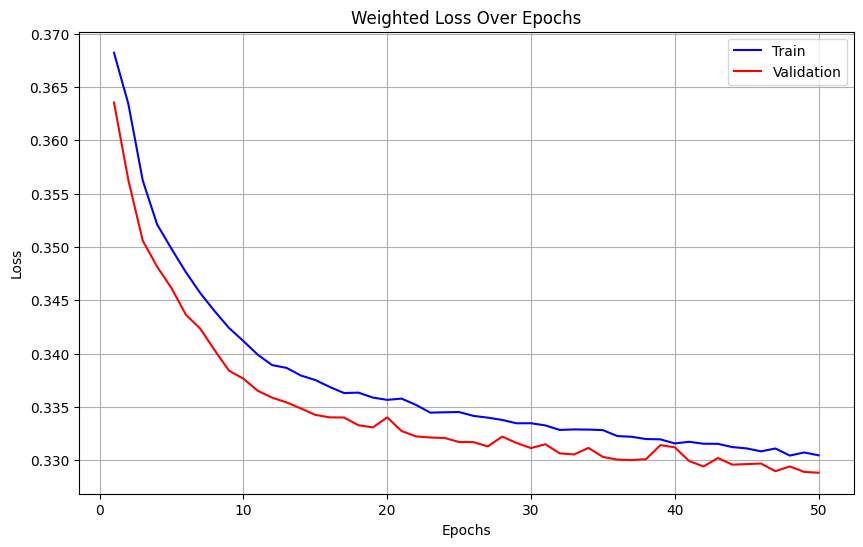

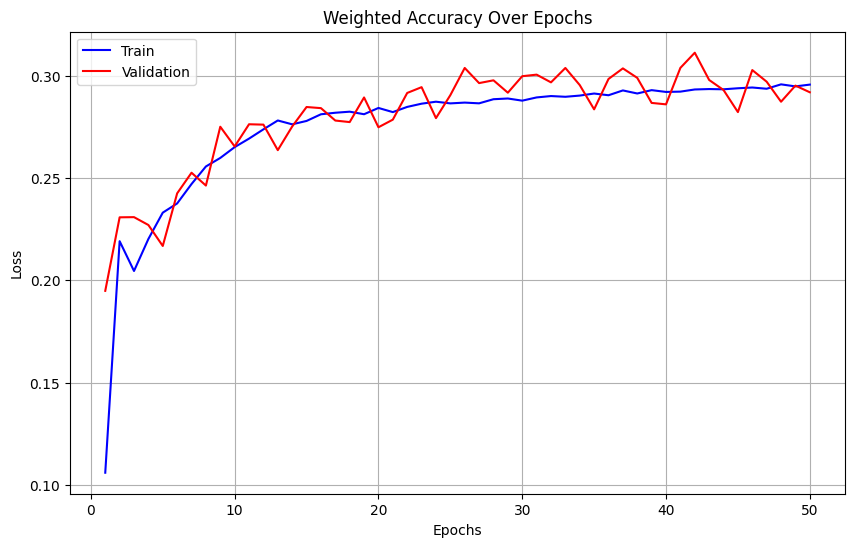

In [26]:
plot_losses(w_train_losses, w_val_losses, "Weighted Loss Over Epochs")
plot_accs(w_train_accs, w_val_accs, "Weighted Accuracy Over Epochs")